## **Flight Fare Prediction (PRCP-1025)**

**Problem Statement**

Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable. That’s why we will try to use machine learning to solve this problem. This can help airlines by predicting what prices they can maintain.

**Task 1**:-Prepare a complete data analysis report on the given data.

**Task 2**:-Create a predictive model which will help the customers to predict future flight prices and plan their journey accordingly.


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Load dataset
data = pd.read_excel('Flight_Fare.xlsx')
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### **Basic checks**

In [ ]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
data.shape

(10683, 11)

In [ ]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
data.describe(include='object')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [ ]:
data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
for i in data.columns:
    print(i,':',data[i].unique())
    print('-----------------------------------------------------------------------')

Airline : ['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
-----------------------------------------------------------------------
Date_of_Journey : ['24/03/2019' '1/05/2019' '9/06/2019' '12/05/2019' '01/03/2019'
 '24/06/2019' '12/03/2019' '27/05/2019' '1/06/2019' '18/04/2019'
 '9/05/2019' '24/04/2019' '3/03/2019' '15/04/2019' '12/06/2019'
 '6/03/2019' '21/03/2019' '3/04/2019' '6/05/2019' '15/05/2019'
 '18/06/2019' '15/06/2019' '6/04/2019' '18/05/2019' '27/06/2019'
 '21/05/2019' '06/03/2019' '3/06/2019' '15/03/2019' '3/05/2019'
 '9/03/2019' '6/06/2019' '24/05/2019' '09/03/2019' '1/04/2019'
 '21/04/2019' '21/06/2019' '27/03/2019' '18/03/2019' '12/04/2019'
 '9/04/2019' '1/03/2019' '03/03/2019' '27/04/2019']
-----------------------------------------------------------------------
Source : ['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
----------

**Insights:**
1. Understanding columns:
    - Categorical columns: 'Airline',  'Source', 'Destination', 'Route','Total_Stops', 'Additional_Info'.
    - Data/Time columns: 'Date_of_Journey','Dep_Time', 'Arrival_Time', 'Duration'.
    - Target column: Price.
2. Date_of_Journey: Extract Day and month.
3. Dep_Time: Extract Hours and minutes.
4. Arrival_Time: Extract Hours, minutes and date(if next day=1 else 0).
5. Total_Stops: Do ordinal encoding(non-stop=0, 1 stops=1, 2 stop=2, 3 stops=3, 4 stops=4).
6. Source: Some Spelling mistakes and One-Hot Encoding.
7. Destination: Some Spelling mistakes and One-Hot Encoding.
8. Routes: Check the importance (no importance then drop column).
9. Additional_Info: Do spelling correction and One-Hot Encoding.
10. Duration: Convert into total minutes.
11. Missing values in Route and Total_Stops


In [ ]:
data_cleaned = data.copy()

In [ ]:
# Extracting Month and day from Date_of_Journey
data_cleaned['Journey_day'] = pd.to_datetime(data_cleaned['Date_of_Journey']).dt.day
data_cleaned['Journey_month'] = pd.to_datetime(data_cleaned['Date_of_Journey']).dt.month
data_cleaned.drop(['Date_of_Journey'],axis=1,inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [ ]:
# Extracting Hours and minutes from Departure time.
data_cleaned['Dep_hour'] = pd.to_datetime(data_cleaned['Dep_Time']).dt.hour
data_cleaned['Dep_min'] = pd.to_datetime(data_cleaned['Dep_Time']).dt.minute
data_cleaned.drop(['Dep_Time'],axis=1,inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [ ]:
# In 'Arrival_Time' column, it includes the time and date if it is reaching on the next day=1 else 0.
# So we need to handle those values.
data_cleaned['Arr_time'] = data_cleaned['Arrival_Time'].apply(lambda x: x.split(' ')[0]) # splitted the time and date

In [ ]:
# Extracting hours and mintues from Arr_time
data_cleaned['Arr_hour'] = pd.to_datetime(data_cleaned['Arr_time']).dt.hour
data_cleaned['Arr_min'] = pd.to_datetime(data_cleaned['Arr_time']).dt.minute
data_cleaned.drop(['Arr_time'],axis=1,inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [ ]:
# If Arrival_Time has date(next day) = 1 else = 0
data_cleaned['Arrival_next_day'] = data['Arrival_Time'].apply(lambda x: 1 if len(x.split(' ')) > 1 else 0)
data_cleaned.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25,1
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,0


In [ ]:
# Remove 'Arrival_Time'
data_cleaned.drop(['Arrival_Time'],axis=1,inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25,1
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,0


In [ ]:
# Convert 'Duration' into Total minutes
# creating a function for conversion
def duration_to_min(x):
  hours = 0
  minutes = 0
  if 'h' in x:
    hours = int(x.split('h')[0])

  if 'm' in x:
    minutes = int(x.split('h')[-1].replace('m',''))

  return hours*60+minutes

duration_to_min('2h 50m')

170

In [ ]:
#Applying the function
data_cleaned['Duration_min'] = data_cleaned['Duration'].apply(duration_to_min)
data_cleaned.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,1,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,0,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25,1,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,0,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,0,285


In [ ]:
# Dropping Duration column
data_cleaned.drop(['Duration'],axis=1,inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day,Duration_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,1,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,0,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,0,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,0,285


In [ ]:
# Cleaning Source, Destination and Additional_Info
data_cleaned['Source'].replace({'Banglore':'Bangalore', 'Delhi':'New Delhi'}, inplace=True)
data_cleaned['Destination'].replace({'Banglore':'Bangalore', 'Delhi':'New Delhi'}, inplace=True)
data_cleaned['Additional_Info'].replace({'No Info':'No info'}, inplace=True)
print(data_cleaned['Source'].unique())
print(data_cleaned['Destination'].unique())
print(data_cleaned['Additional_Info'].unique())

['Bangalore' 'Kolkata' 'New Delhi' 'Chennai' 'Mumbai']
['New Delhi' 'Bangalore' 'Cochin' 'Kolkata' 'Hyderabad']
['No info' 'In-flight meal not included' 'No check-in baggage included'
 '1 Short layover' '1 Long layover' 'Change airports' 'Business class'
 'Red-eye flight' '2 Long layover']


In [ ]:
# Handling missing values
data_cleaned[data_cleaned.Total_Stops.isnull()]

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day,Duration_min
9039,Air India,New Delhi,Cochin,NaN,NaN,No info,7480,6,5,9,45,9,25,1,1420


In [ ]:
# Dropping null value row
data_cleaned.drop(data_cleaned[data_cleaned.Total_Stops.isnull()].index, axis=0, inplace=True)
data_cleaned.isnull().sum()

,0
Airline,0
Source,0
Destination,0
Route,0
Total_Stops,0
Additional_Info,0
Price,0
Journey_day,0
Journey_month,0
Dep_hour,0


In [ ]:
data_cleaned

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day,Duration_min
0,IndiGo,Bangalore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,1,170
1,Air India,Kolkata,Bangalore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,0,445
2,Jet Airways,New Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1,1140
3,IndiGo,Kolkata,Bangalore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,0,325
4,IndiGo,Bangalore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,0,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Bangalore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,0,150
10679,Air India,Kolkata,Bangalore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,0,155
10680,Jet Airways,Bangalore,New Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,0,180
10681,Vistara,Bangalore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,0,160


### **Exploratory Data Analysis**

In [ ]:
data_num = data_cleaned[['Price','Journey_day', 'Journey_month', 'Dep_hour', 'Dep_min', 'Arr_hour', 'Arr_min', 'Duration_min']] # Numerical columns
data_cat = data_cleaned[['Airline', 'Source', 'Destination', 'Route', 'Total_Stops','Additional_Info', 'Arrival_next_day']] # Categorical columns

**1. Bivariate Analysis**

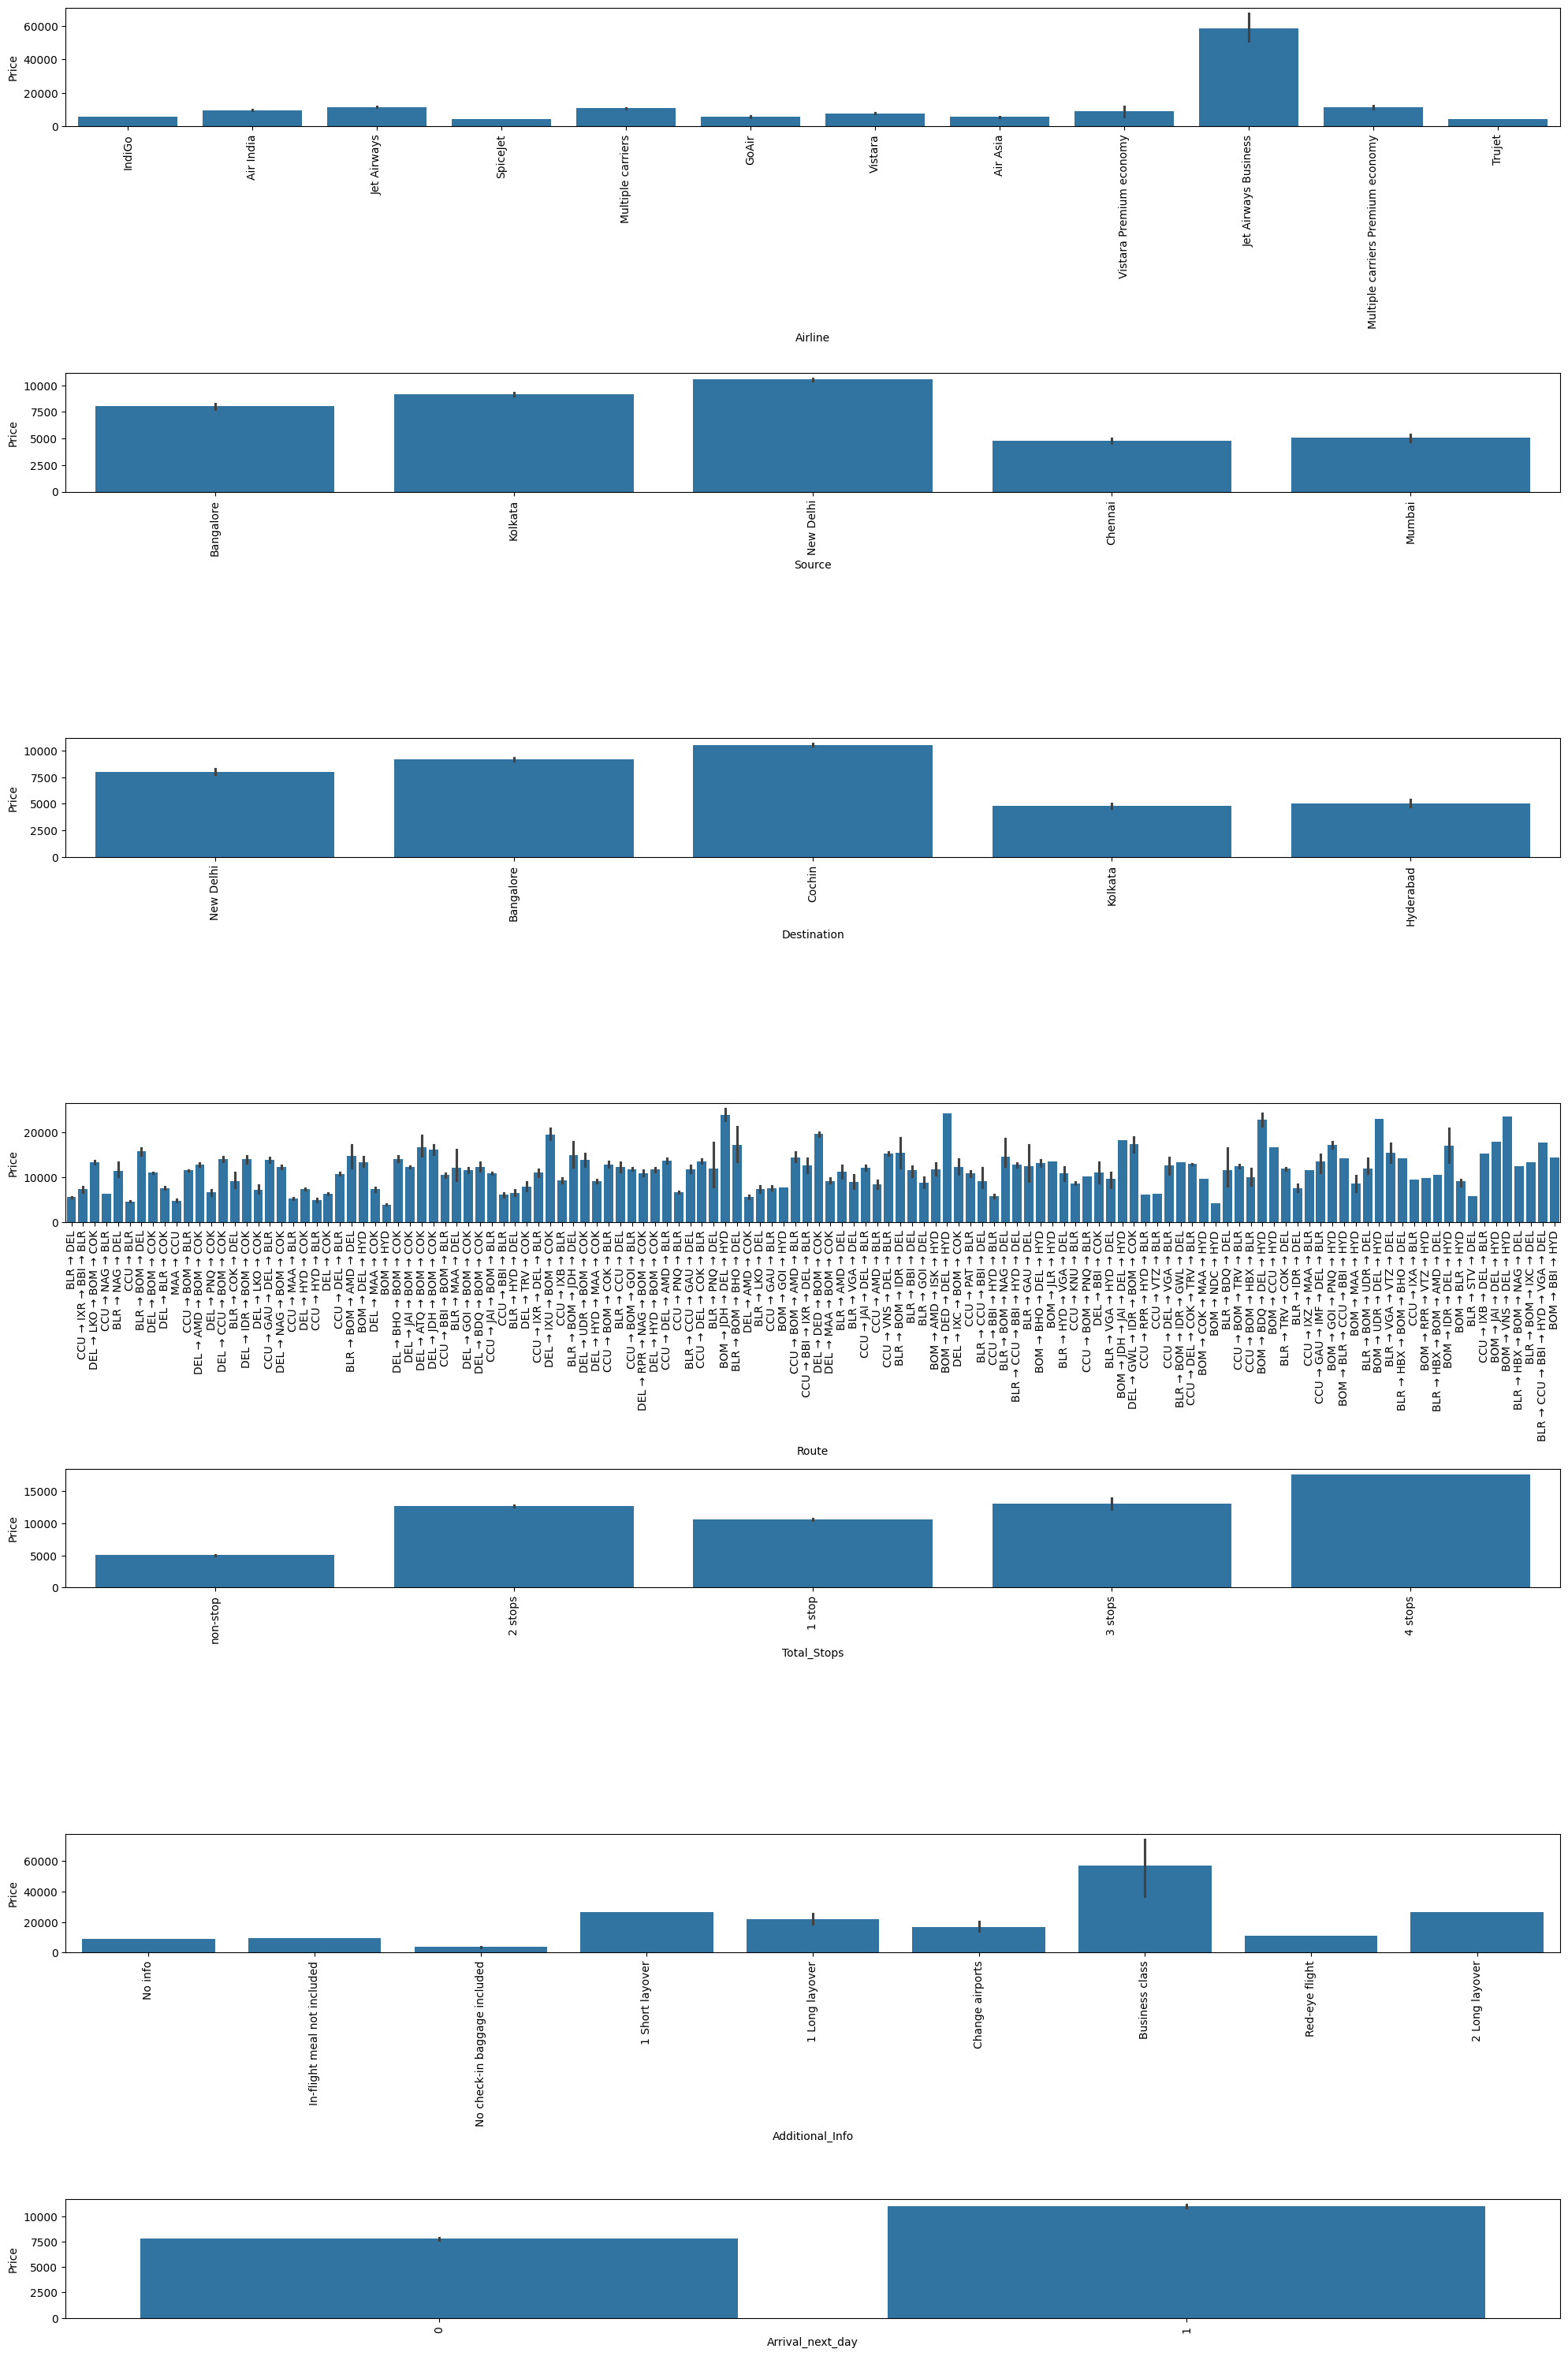

In [ ]:
# Check Average comparison
plt.figure(figsize=(20, 30))
pltNo = 1
for column in data_cat:
  ax = plt.subplot(7, 1, pltNo)
  sns.barplot(x=data_cat[column].dropna(), y=data_cleaned['Price'])
  plt.xticks(rotation=90)
  pltNo += 1
plt.tight_layout()
plt.show()

Insights:
- Airline: Jet Airways Business class has the highest average on pricing.
- Source: Flights starting from New Delhi Charges more compared to other cities.
- Destination: Flights arriving at Cochin has the highest avg price.
- Route: Flights having multiple stops(for example, BOM → VNS → DEL → HYD) are have higher price.
- Total_Stops: 4 stops having more charge.
- Additional_Info: Business class having more charge then others.
- Arrival_next_day: Flights arriving next day having more charge.

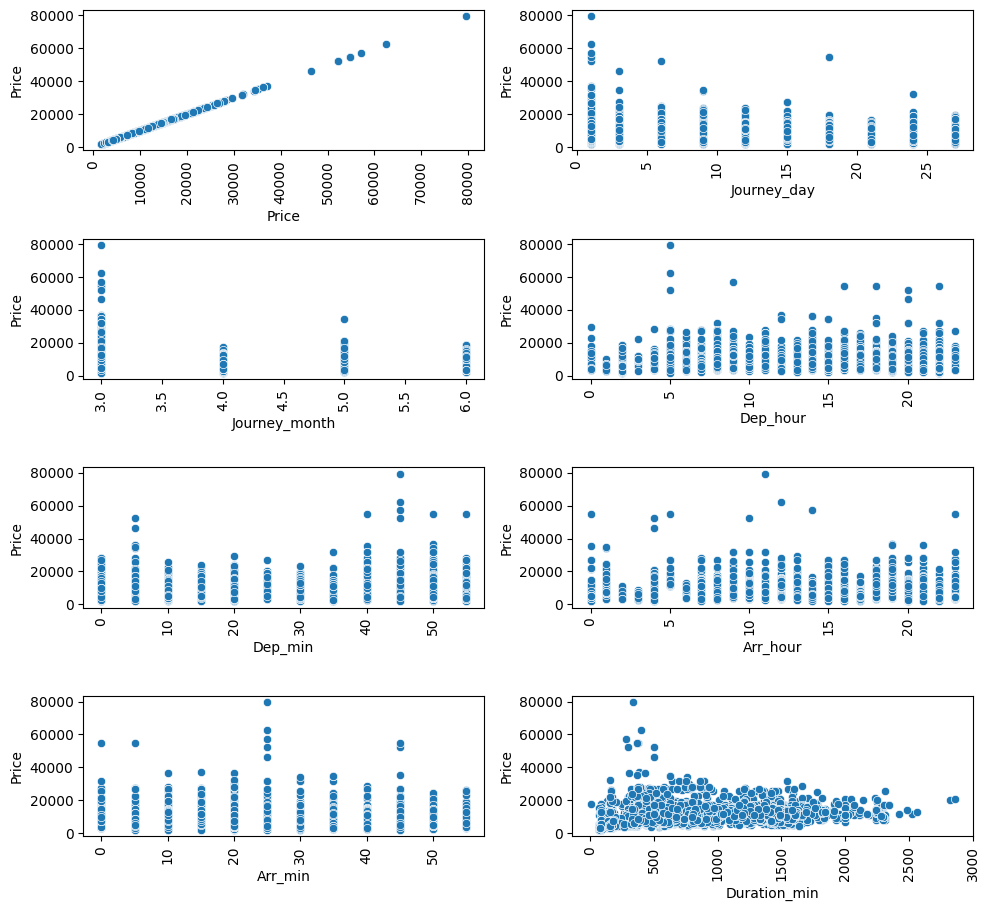

In [ ]:
# Check relationship
plt.figure(figsize=(10, 20))
pltNo = 1
for column in data_num:
  ax = plt.subplot(9, 2, pltNo)
  sns.scatterplot(x=data_num[column], y=data['Price'])
  plt.xticks(rotation=90)
  pltNo += 1
plt.tight_layout()
plt.show()

Insights:
- price-Duration_min --> Clear upward trend up to 1500 mins, then prices stabilize.

**2. Univariate Analysis**

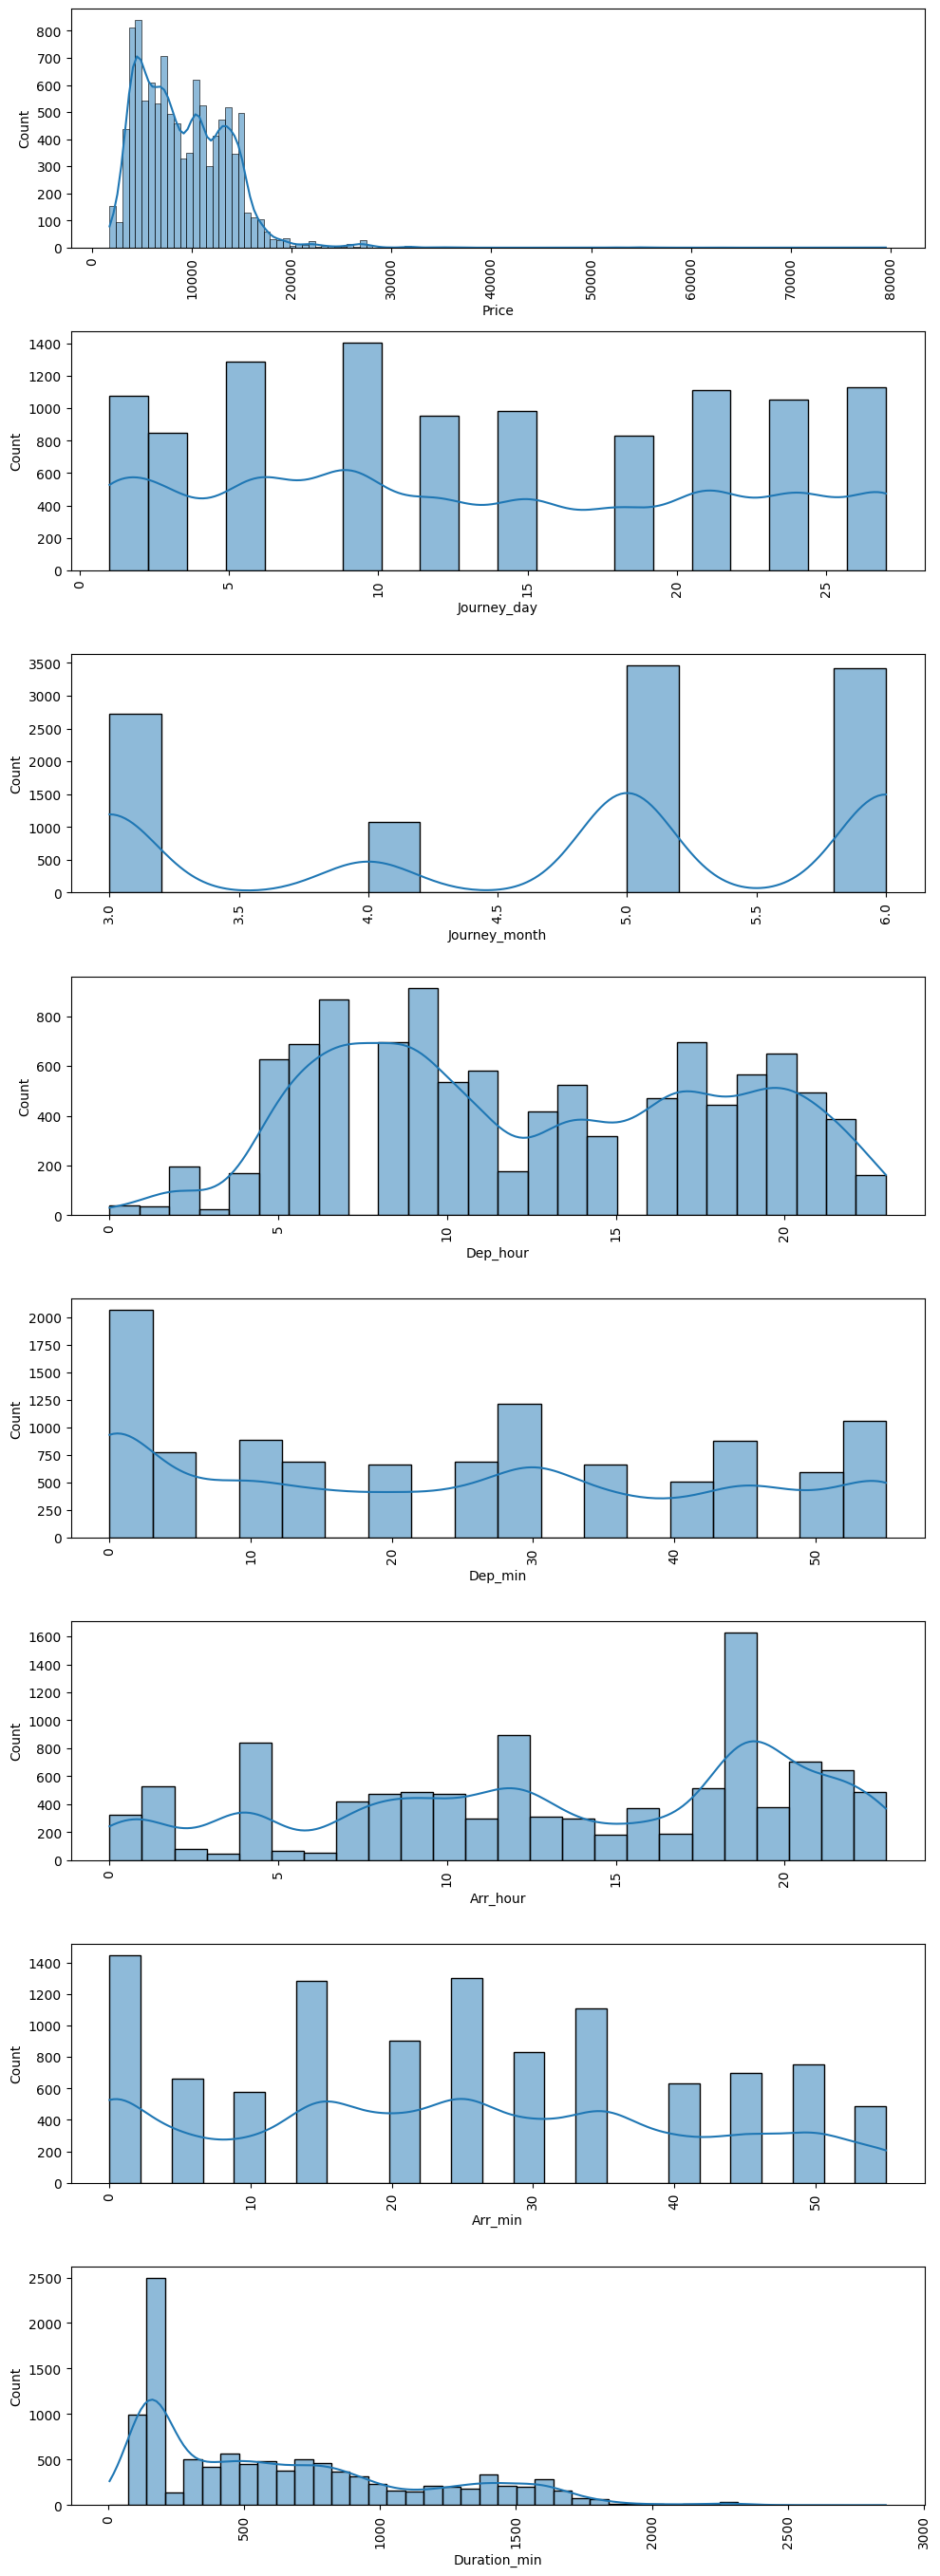

In [ ]:
# Check distribution
plt.figure(figsize=(10, 30))
pltNo = 1
for column in data_num:
  ax = plt.subplot(9, 1, pltNo)
  sns.histplot(data_num[column].dropna(), kde=True)
  plt.xticks(rotation=90)
  pltNo += 1
plt.tight_layout()
plt.show()

Insights:
- Price: Right skewed, most values are between 1000 and 20000, with some high - outliers.
- Journey_day: Flights exist on almost all days, data is evenly distributed.
- Journey_month: May and June have higher frequency (late summer).
- Dep_hour: Most flights depart in morning and evening (high frequency time slots).
- Dep_min: No significant pattern observed.
- Arr_hour: Slightly more flights arrive during evening/night.
- Arr_min: No significant pattern observed.
- Duration_min: Right skewed, most flights are around shorter durations (~150 min), with some long-duration outliers.

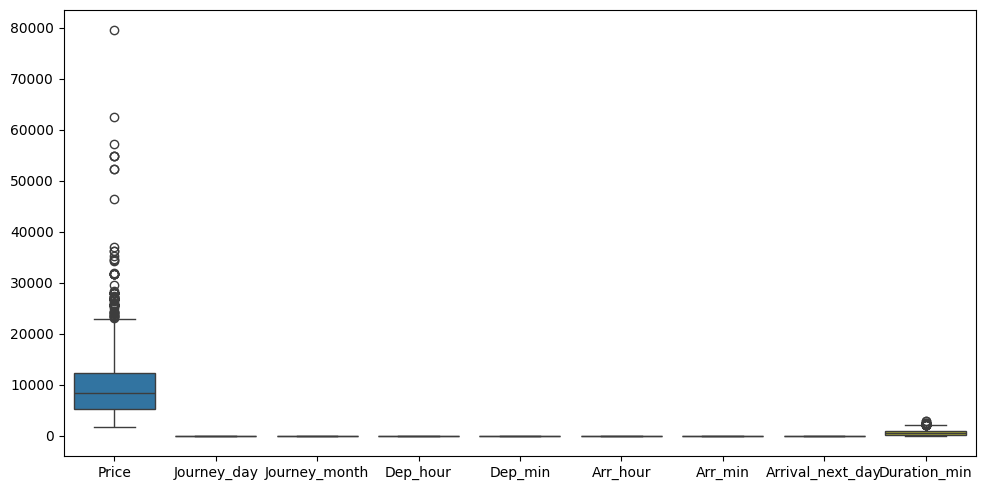

In [ ]:
# Check outliers
plt.figure(figsize=(10, 5), facecolor='white')
sns.boxplot(data=data_cleaned)
plt.tight_layout()
plt.show()

Insight:
- Price: Target variable has more number of outliers. (try to use log transform)

**3. Multivariate Analysis**

<Axes: >

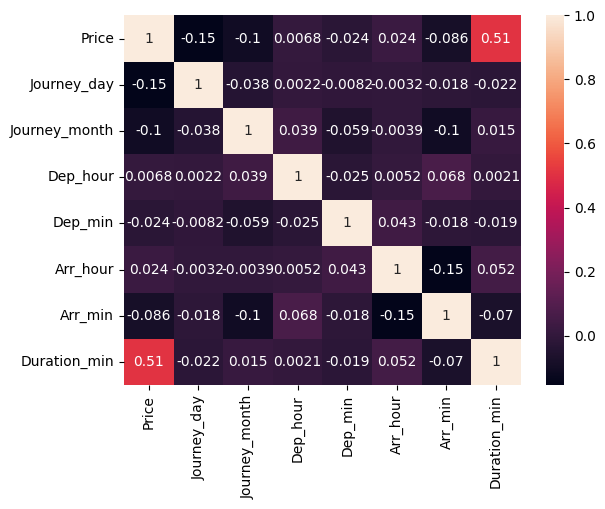

In [ ]:
# Check Correlation
sns.heatmap(data_num.corr(), annot=True)

Insights:

Price -> Duration_min = 0.51 (Strong Positive correlation): Longer duration flights charges higher price.



In [ ]:
# Average price per airline
data_cleaned.groupby('Airline')['Price'].mean().sort_values()

,Price
Airline,
Trujet,4140.000000
SpiceJet,4338.284841
Air Asia,5590.260188
IndiGo,5673.682903
GoAir,5861.056701
Vistara,7796.348643
Vistara Premium economy,8962.333333
Air India,9612.427756
Multiple carriers,10902.678094


### **EDA Report**

1. Duration(minutes) of the flights is a important feature which is affecting price.
2. Number of stops significantly changing the ticket price.
3. Time based feature (Dep_hour and Arr_hour) have moderate impact.
4. Dep_min and Arr_min have very low impact so it is better to remove those features.
5. Route of the flight is not needed, because we already have the information about Source, Destination and Total_stops.
6. Target features have some outliers (try Log transform).
7. Flights arrving next day has moderate impact in pricing.

In [ ]:
data_cleaned.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arr_hour,Arr_min,Arrival_next_day,Duration_min
0,IndiGo,Bangalore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,1,170
1,Air India,Kolkata,Bangalore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,0,445
2,Jet Airways,New Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1,1140
3,IndiGo,Kolkata,Bangalore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,0,325
4,IndiGo,Bangalore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,0,285


In [ ]:
# Dropping unwanted features
data_cleaned.drop(['Dep_min', 'Arr_min', 'Route'], axis=1, inplace=True)
data_cleaned.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min
0,IndiGo,Bangalore,New Delhi,non-stop,No info,3897,24,3,22,1,1,170
1,Air India,Kolkata,Bangalore,2 stops,No info,7662,1,5,5,13,0,445
2,Jet Airways,New Delhi,Cochin,2 stops,No info,13882,9,6,9,4,1,1140
3,IndiGo,Kolkata,Bangalore,1 stop,No info,6218,12,5,18,23,0,325
4,IndiGo,Bangalore,New Delhi,1 stop,No info,13302,1,3,16,21,0,285


In [ ]:
# Ordinal Encoding (Total_Stops)
data_cleaned['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [ ]:
stop_mapping= {
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
}
data_cleaned['Total_Stops'] = data_cleaned['Total_Stops'].map(stop_mapping)
data_cleaned.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min
0,IndiGo,Bangalore,New Delhi,0,No info,3897,24,3,22,1,1,170
1,Air India,Kolkata,Bangalore,2,No info,7662,1,5,5,13,0,445
2,Jet Airways,New Delhi,Cochin,2,No info,13882,9,6,9,4,1,1140
3,IndiGo,Kolkata,Bangalore,1,No info,6218,12,5,18,23,0,325
4,IndiGo,Bangalore,New Delhi,1,No info,13302,1,3,16,21,0,285


In [ ]:
data_cleaned['Total_Stops'].value_counts()

,count
Total_Stops,
1,5625
0,3491
2,1520
3,45
4,1


In [ ]:
# One-Hot Encoding (Airline, Source, Destination, Additional_Info)
OHE = OneHotEncoder(handle_unknown='ignore')
data_ohe = OHE.fit_transform(data_cleaned[['Airline', 'Source', 'Destination', 'Additional_Info']]).toarray()
data_ohe_df = pd.DataFrame(data_ohe, columns=OHE.get_feature_names_out(), index=data_cleaned.index)
data_ohe_df.head()


,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Destination_New Delhi,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
data_cleaned.drop(['Airline', 'Source', 'Destination', 'Additional_Info'], axis=1, inplace=True) # Dropped the raw features
data_encoded = pd.concat([data_cleaned, data_ohe_df], axis=1) # Concatinate encoded with data_cleaned
data_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Destination_New Delhi,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,3897,24,3,22,1,1,170,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,7662,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,13882,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,6218,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,13302,1,3,16,21,0,285,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Log transform Target feature(Price) to avoid the heavy Skewness.
data_encoded['Price'] = np.log1p(data_encoded['Price'])
# After the prediction we need convert the Log value back to normal.

In [ ]:
# Define X and y
X = data_encoded.drop(['Price'], axis=1)
y = data_encoded['Price']

In [ ]:
# Splitting train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8545, 38)
(2137, 38)
(8545,)
(2137,)


In [ ]:
y_train

,Price
10005,9.121509
3684,9.423353
1034,8.627661
3909,8.948456
3088,9.390409
...,...
5734,9.412710
5191,9.291459
5390,8.945202
860,8.723394


In [ ]:
y_train.isna().sum()

np.int64(0)

### **Model Creation**

In [ ]:
# Model-1 RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)

y_pred_log = model_rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [ ]:
# Model-1 Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MSE: 2740965.3832432074
MAE: 677.548842175594
RMSE: 1655.5861147168416
R2: 0.8728801491826286


In [ ]:
# Comparing train and test (R2_score)
def train_vs_test(model):
  y_train_pred_log = model.predict(X_train)
  y_train_pred = np.expm1(y_train_pred_log)
  y_train_actual = np.expm1(y_train)

  y_test_pred_log = model.predict(X_test)
  y_test_pred = np.expm1(y_test_pred_log)
  y_test_actual = np.expm1(y_test)

  print('Train R2:',r2_score(y_train_actual, y_train_pred))
  print('Test R2:',r2_score(y_test_actual, y_test_pred))

In [ ]:
train_vs_test(model_rf)

Train R2: 0.975328687561376
Test R2: 0.8728801491826286


Model-1 (RandomForestReggessor) : Slight overfitting
- Test R² = 0.87  still very good
- But train r2 is 97.5% and test r2 is 87.2% (10% gap)

In [ ]:
# Model-2 RandomForestRegressor Hyperparameter tuned
from sklearn.model_selection import RandomizedSearchCV

model_rf2 = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators':[100,200,300,400,500],
    'max_depth':[None,10,20,30,40,50],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']
}

random_search = RandomizedSearchCV(
    model_rf2,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='r2', verbose=1)

In [ ]:
# Get best model
best_model_rf = random_search.best_estimator_
print('Best parameters:',random_search.best_params_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
# Defining a function for model prediction and evaluation
def pred(model):
  y_pred_log = model.predict(X_test)
  y_pred = np.expm1(y_pred_log)
  y_test_actual = np.expm1(y_test)

  mse = mean_squared_error(y_test_actual, y_pred)
  mae = mean_absolute_error(y_test_actual, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test_actual, y_pred)
  print('MSE:', mse)
  print('MAE:', mae)
  print('RMSE:', rmse)
  print('R2:', r2)


In [ ]:
pred(best_model_rf)

MSE: 2938181.1298532267
MAE: 831.1893843031879
RMSE: 1714.1123445834075
R2: 0.8637337234593535


In [ ]:
train_vs_test(best_model_rf)

Train R2: 0.960566250747821
Test R2: 0.8637337234593535


Model-2 (RFT Tuned): Lower performance than Model-1
- Test R² = 0.86
- Train r2 is 96.0% and test r2 is 86.3% (~10% gap)

In [ ]:
# Model-3 XGBoosting
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

model_xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred(model_xgb)

MSE: 2801810.5566689004
MAE: 890.4486378735338
RMSE: 1673.860972921258
R2: 0.8700582859748272


In [ ]:
train_vs_test(model_xgb)

Train R2: 0.9087123240016762
Test R2: 0.8700582859748272


Model-3 (XGB) : Good model and lower overfitting
- Test R² = 0.87  still very good
- But train r2 is 90.8% and test r2 is 87.0% (~3% gap)

In [ ]:
# Model-4 XGBoosting hyperparameter tuned

model_xgb2 = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,4,5,6],
    'learning_rate':[0.01,0.1,0.2],
}

random_search_xgb = RandomizedSearchCV(
    model_xgb2,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
best_model_xgb = random_search_xgb.best_estimator_
print('Best params:',random_search_xgb.best_params_)

Best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2}


In [ ]:
pred(best_model_xgb)

MSE: 1968886.480898126
MAE: 699.4171677813889
RMSE: 1403.1701539364803
R2: 0.9086874437531336


In [ ]:
train_vs_test(best_model_xgb)

Train R2: 0.9753020022545749
Test R2: 0.9086874437531336


Model-4 (XGB Tuned): Better performance but slight overfitting
- Test R² = 0.90  Better r2 score
- Train r2 is 97.5% and test r2 is 90.8% (~7% gap)

In [ ]:
# Model-5 LightGBM
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(
  n_estimators=500,
  learning_rate=0.05,
  num_leaves=35,
  max_depth=-1,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42
  )

model_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 28
[LightGBM] [Info] Start training from score 8.989118


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              num_leaves=35, random_state=42, subsample=0.8)

In [ ]:
pred(model_lgbm)

MSE: 2721461.034870239
MAE: 802.2002599942817
RMSE: 1649.685132038911
R2: 0.8737847172850276


In [ ]:
train_vs_test(model_lgbm)

Train R2: 0.9209956761656526
Test R2: 0.8737847172850276


Model-5 (LightGBM): slight overfitting

- Test R² = 0.87, weak r2 score comapare to other models
- Train r2 is 92% and test r2 is 87.3% (~5% gap)


In [ ]:
lgbm = LGBMRegressor(random_state=42, verbose=-1)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50, 100],
    'subsample': [0.7, 0.8, 1.0]
}

lgbm_random = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
)

lgbm_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=LGBMRegressor(random_state=42, verbose=-1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'n_estimators': [100, 200, 300],
                                        'num_leaves': [31, 50, 100],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [ ]:
best_model_lgbm = lgbm_random.best_estimator_
print('Best params:',lgbm_random.best_params_)

Best params: {'subsample': 0.7, 'num_leaves': 100, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}


In [ ]:
pred(best_model_lgbm)

MSE: 2733337.377998281
MAE: 732.1022935410633
RMSE: 1653.2807922425884
R2: 0.8732339190239762


In [ ]:
train_vs_test(best_model_lgbm)

Train R2: 0.9577827808105889
Test R2: 0.8732339190239762


Model-6 (LightGBM Tuned): slight overfitting

- Test R² = 0.87, weak r2 score same as initial LGBM model
- Train r2 is 95% and test r2 is 87.3% (~8% gap)


### **Feature Engineering**
- Is_weekend
    - create a Journey_date using Journey_day + Journey_month + 2019
    - create Day_of_week using Journey_date (0 = Mon, 1 = Tue, ... 6 = Sun)
    - create Is_weekend (if Day_of_week is 5, 6 then 1 else 0)
- Time_of_day: Late night, Morning, Afternoon, Evening, Night.
    - 0 to 4 = Late night
    - 5 to 11 = Morning
    - 12 to 16 = Afternoon
    - 17 to 20 = Evening
    - 21 t0 23 = Night


In [ ]:
# Is_weekend
data_encoded['Journey_date'] = pd.to_datetime(data_encoded['Journey_day'].astype(str) + '-' + data_encoded['Journey_month'].astype(str) + '-2019', format='%d-%m-%Y')
data_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Journey_date
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-24
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-01
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-06-09
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-12
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-01


In [ ]:
data_encoded['Day_of_week'] = data_encoded['Journey_date'].dt.dayofweek # To find the day of the week
data_encoded['Is_weekend'] = data_encoded['Day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
data_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Journey_date,Day_of_week,Is_weekend
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-24,6,1
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-01,2,0
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-06-09,6,1
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-12,6,1
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-01,4,0


In [ ]:
# Time_of_day
# Definig a function
def time_of_day(hour):
  if hour < 5:          # 0-4 -> Late night
    return 'Late night'
  elif hour < 12:       # 5-11 -> Morning
    return 'Morning'
  elif hour < 17:       # 12-16 -> Afternoon
    return 'Afternoon'
  elif hour < 21:       # 17-20 -> Evening
    return 'Evening'
  else:
    return 'Night'      # 21-23 -> Night

data_encoded['Time_of_day'] = data_encoded['Dep_hour'].apply(time_of_day)

In [ ]:
data_encoded

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Journey_date,Day_of_week,Is_weekend,Time_of_day
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-24,6,1,Night
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-01,2,0,Morning
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-06-09,6,1,Morning
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-05-12,6,1,Evening
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-01,4,0,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,8.320692,9,4,19,22,0,150,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-04-09,1,0,Evening
10679,0,8.329899,27,4,20,23,0,155,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-04-27,5,1,Evening
10680,0,8.885994,27,4,8,11,0,180,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-04-27,5,1,Morning
10681,0,9.445333,1,3,11,14,0,160,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2019-03-01,4,0,Morning


In [ ]:
data_encoded.drop(['Journey_date', 'Day_of_week'], axis=1, inplace=True)
data_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Is_weekend,Time_of_day
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Night
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,Morning
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Morning
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Evening
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,Afternoon


In [ ]:
data_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Is_weekend,Time_of_day
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Night
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,Morning
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Morning
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,Evening
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,Afternoon


In [ ]:
# OHE encoding Time_of_weekend
OHE = OneHotEncoder(handle_unknown='ignore')
data_ohe = OHE.fit_transform(data_encoded[['Time_of_day']]).toarray()
data_ohe_df = pd.DataFrame(data_ohe, columns=OHE.get_feature_names_out(), index=data_encoded.index)
data_FE = pd.concat([data_encoded, data_ohe_df], axis=1)
data_FE.drop(['Time_of_day'], axis=1, inplace=True)
data_FE.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Arr_hour,Arrival_next_day,Duration_min,Airline_Air Asia,Airline_Air India,...,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Is_weekend,Time_of_day_Afternoon,Time_of_day_Evening,Time_of_day_Late night,Time_of_day_Morning,Time_of_day_Night
0,0,8.268219,24,3,22,1,1,170,0.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,0.0,1.0
1,2,8.944159,1,5,5,13,0,445,0.0,1.0,...,0.0,0.0,1.0,0.0,0,0.0,0.0,0.0,1.0,0.0
2,2,9.538420,9,6,9,4,1,1140,0.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,0.0,0.0,1.0,0.0
3,1,8.735364,12,5,18,23,0,325,0.0,0.0,...,0.0,0.0,1.0,0.0,1,0.0,1.0,0.0,0.0,0.0
4,1,9.495745,1,3,16,21,0,285,0.0,0.0,...,0.0,0.0,1.0,0.0,0,1.0,0.0,0.0,0.0,0.0


In [ ]:
data_FE.columns

Index(['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Arr_hour', 'Arrival_next_day', 'Duration_min', 'Airline_Air Asia',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Bangalore', 'Source_Chennai', 'Source_Kolkata', 'Source_Mumbai',
       'Source_New Delhi', 'Destination_Bangalore', 'Destination_Cochin',
       'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Long layover', 'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No check-in baggage included',
  

In [ ]:
# Define X and y
X = data_FE.drop(['Price'], axis=1)
y = data_FE['Price']

In [ ]:
# Splitting train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model training after Feature engineering
model_rf.fit(X_train, y_train)
pred(model_rf)
print('---------------------------------')
train_vs_test(model_rf)

MSE: 2710525.71944793
MAE: 667.8759097592384
RMSE: 1646.3674314829998
R2: 0.8742918727834601
---------------------------------
Train R2: 0.9746218978073696
Test R2: 0.8742918727834601


In [ ]:
best_model_rf.fit(X_train, y_train)
pred(best_model_rf)
print('---------------------------------')
train_vs_test(best_model_rf)

MSE: 3223832.5134610017
MAE: 885.8267907904291
RMSE: 1795.5034150513336
R2: 0.8504858504683307
---------------------------------
Train R2: 0.9583819899175617
Test R2: 0.8504858504683307


In [ ]:
model_xgb.fit(X_train, y_train)
pred(model_xgb)
print('---------------------------------')
train_vs_test(model_xgb)

MSE: 2552946.0446036556
MAE: 881.7697074151115
RMSE: 1597.79411834055
R2: 0.8816000660501522
---------------------------------
Train R2: 0.9087406000225333
Test R2: 0.8816000660501522


In [ ]:
best_model_xgb.fit(X_train, y_train)
pred(best_model_xgb)
print('---------------------------------')
train_vs_test(best_model_xgb)

MSE: 1896250.6188907367
MAE: 692.6796787031687
RMSE: 1377.0441601091582
R2: 0.9120561327554898
---------------------------------
Train R2: 0.9741427526802985
Test R2: 0.9120561327554898


In [ ]:
model_lgbm.fit(X_train, y_train)
pred(model_lgbm)
print('---------------------------------')
train_vs_test(model_lgbm)

MSE: 2746024.3854190493
MAE: 800.1068692059996
RMSE: 1657.1132687354384
R2: 0.8726455239641528
---------------------------------
Train R2: 0.9191963564053525
Test R2: 0.8726455239641528


In [ ]:
best_model_lgbm.fit(X_train, y_train)
pred(best_model_lgbm)
print('---------------------------------')
train_vs_test(best_model_lgbm)

MSE: 2690114.874207806
MAE: 727.8525897086909
RMSE: 1640.156966332127
R2: 0.8752384821853311
---------------------------------
Train R2: 0.9595804280609461
Test R2: 0.8752384821853311


## **Model Comparison Report (After feature engineering)**

1. RandomForestRegressor (Initial):
   - MAE: 667 (Lower error prediction)
   - RMSE: 1646 (Larger prediction errors)
   - Test R2: 0.874 (Good performance)
   - Train R2: 0.974 (Slight overfitting)
   - Overall: Good model but slightly overfitting, higher prediction error.

2. RandomForestRegressor (Tuned):
   - MAE: 885 (Error increased bad predictions)
   - RMSE: 1795 (Larger prediction errors)
   - Test R2: 0.850 (Decreased the R2 score, but still Good model)
   - Train R2: 0.958 (Slight overfitting)
   - Overall: Tuning reduced performance & initial model is better

3. XGBoosting (Initial):
   - MAE: 881 (Error increased bad predictions)
   - RMSE: 1597 ( moderate error prediction)
   - Test R2: 0.881 (Good performance)
   - Train R2:0.908 (very less overfitting, good generaliation)
   - Overall: Balanced model with good generalization, but higher prediction error.


4. XGBoosting (Tuned):
   - MAE: 692 (Reduced error and better prediction)
   - RMSE: 1377 ( comparitively lower error prediction)
   - Test R2: 0.912 (best among all other models)
   - Train R2: 0.974 (Slight overfitting, but it is acceptable)
   - Overall: significantly improved after hyperparameter tuning.

5. LightGBM (Initial):
   - MAE: 800 (Moderate prediction error)
   - RMSE: 1657 (larger errors presented)
   - Test R2: 0.872 (Good performance)
   - Train R2:0.919 (Low overfitting)
   - Overall: Balanced model with good generalization but slightly higher error.

6. LightGBM (Tuned):
   - MAE: 727 (Reduced error, when compared to intial)
   - RMSE: 1640 (Slight improvement, but still large errors presented)
   - Test R2: 0.875 (Slightly increased)
   - Train R2: 0.959 (Increased overfitting)
   - Overall: Tuning slightly improved performance but increased overfitting.


The **Tuned XGBoost model** was selected as the final model because:
- It achieved the highest test R² (~0.91)
- It has the lowest prediction error (MAE ~ ₹700)
- It balances performance and generalization is better than other models.


## **Report on Challenges faced**

-  Spent more time to cleaning and preprocessing the dataset, columns such as Date, Duration, Arrival Time and Departure Time.
-  To find the right features for good prediction and improving model performance was challenging.
-  Model Overfitting is the major challenge in this project.
-  The dataset contained data only from March to June, which is limited the model to learn and predict the full seasonal patterns like peak months, lower flight fare months, holiday months.etc.

In [ ]:
# Saving the model
# import joblib
# joblib.dump(best_model, 'best_model_xgb.pkl')